# Intelligent Credit Risk Assessment System

## Data Loading and Understanding

In [5]:
import pandas as pd
df = pd.read_csv("german_credit_data.csv")
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
dtypes: int64(5), object(5)
memory usage: 78.3+ KB


,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


## Data Preprocessing

In [6]:
# Drop unnecessary column
df = df.drop(columns=['Unnamed: 0'])
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,NaN,little,1169,6,radio/TV
1,22,female,2,own,little,moderate,5951,48,radio/TV
2,49,male,1,own,little,NaN,2096,12,education
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car


In [7]:
df.isnull().sum()

Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
dtype: int64

In [8]:
# Handle missing values
df['Saving accounts'] = df['Saving accounts'].fillna('unknown')
df['Checking account'] = df['Checking account'].fillna('unknown')

In [9]:
df.isnull().sum()

Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
dtype: int64

In [10]:
# Encode categorical variables
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,1,2,1,4,0,1169,6,5
1,22,0,2,1,0,1,5951,48,5
2,49,1,1,1,0,3,2096,12,3
3,45,1,2,0,0,0,7882,42,4
4,53,1,2,0,0,0,4870,24,1


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               1000 non-null   int64
 1   Sex               1000 non-null   int64
 2   Job               1000 non-null   int64
 3   Housing           1000 non-null   int64
 4   Saving accounts   1000 non-null   int64
 5   Checking account  1000 non-null   int64
 6   Credit amount     1000 non-null   int64
 7   Duration          1000 non-null   int64
 8   Purpose           1000 non-null   int64
dtypes: int64(9)
memory usage: 70.4 KB


## Target Variable Creation

In [12]:
df['Risk'] = (df['Credit amount'] > 3000).astype(int)

In [13]:
X = df.drop(['Risk', 'Credit amount'], axis=1)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               1000 non-null   int64
 1   Sex               1000 non-null   int64
 2   Job               1000 non-null   int64
 3   Housing           1000 non-null   int64
 4   Saving accounts   1000 non-null   int64
 5   Checking account  1000 non-null   int64
 6   Credit amount     1000 non-null   int64
 7   Duration          1000 non-null   int64
 8   Purpose           1000 non-null   int64
 9   Risk              1000 non-null   int64
dtypes: int64(10)
memory usage: 78.3 KB


## Feature Selection

In [15]:
X = df.drop(['Risk', 'Credit amount'], axis=1)
y = df['Risk']

#To avoid data leakage, the "Credit amount" feature was removed since it was used to create the target variable.

## Train-Test Split

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Feature Scaling

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model Training - Logistic Regression

In [18]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train, y_train)
print("Train accuracy:", lr.score(X_train, y_train))
print("Test accuracy:", lr.score(X_test, y_test))

Train accuracy: 0.76125
Test accuracy: 0.74


## Model Evaluation (ROC-AUC)

In [19]:
## Evaluation (ROC-AUC)
from sklearn.metrics import roc_auc_score

y_pred = lr.predict_proba(X_test)[:,1]

roc_score = roc_auc_score(y_test, y_pred)

print("ROC-AUC:", roc_score)

ROC-AUC: 0.7859340659340659


## Model Training - Random Forest

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)

rf.fit(X_train, y_train)
print("Train accuracy:", rf.score(X_train, y_train))
print("Test accuracy:", rf.score(X_test, y_test))

Train accuracy: 0.9975
Test accuracy: 0.71


## Random Forest Evaluation

In [21]:
y_pred_rf = rf.predict_proba(X_test)[:,1]

roc_rf = roc_auc_score(y_test, y_pred_rf)

print("Random Forest ROC-AUC:", roc_rf)

Random Forest ROC-AUC: 0.7334615384615385


## Cross Validation

In [22]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='roc_auc')

print("Cross-validation scores:", cv_scores)
print("Average ROC-AUC:", cv_scores.mean())

Cross-validation scores: [0.80027979 0.80422976 0.76069783 0.80694536 0.80233706]
Average ROC-AUC: 0.7948979591836736


## Risk Classification

In [23]:
def risk_category(prob):
    if prob < 0.3:
        return "Low Risk"
    elif prob < 0.7:
        return "Medium Risk"
    else:
        return "High Risk"

df_results = pd.DataFrame({
    "Actual": y_test,
    "Probability": y_pred_rf
})

df_results["Risk Category"] = df_results["Probability"].apply(risk_category)

df_results.head()

,Actual,Probability,Risk Category
521,1,0.55,Medium Risk
737,1,0.21,Low Risk
740,0,0.47,Medium Risk
660,0,0.34,Medium Risk
411,1,0.92,High Risk


## Feature Importance

In [24]:
import pandas as pd

importances = rf.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feat_df.head(10))

            Feature  Importance
6          Duration    0.392768
0               Age    0.222624
7           Purpose    0.096460
2               Job    0.080386
4   Saving accounts    0.068219
5  Checking account    0.061324
3           Housing    0.046431
1               Sex    0.031787


## Credit Amount Graph

This graph shows how the credit amount is distributed among applicants. It helps to understand whether most loans are small or large.

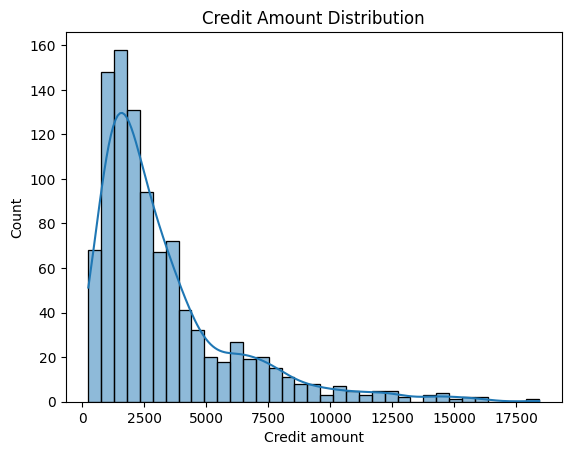

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Credit amount'], kde=True)
plt.title("Credit Amount Distribution")
plt.show()

## Risk Distribution Graph

This graph shows the number of low-risk and high-risk applicants. It helps to understand the balance of the dataset.

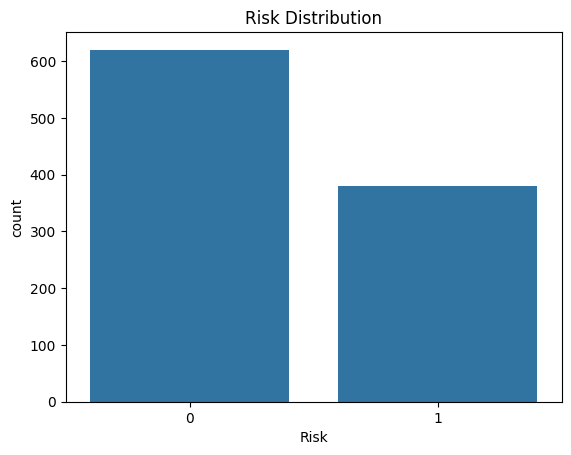

In [26]:
sns.countplot(x='Risk', data=df)
plt.title("Risk Distribution")
plt.show()

## Correlation Heatmap

This heatmap shows the relationship between different features. It helps to identify which variables are strongly related to each other.

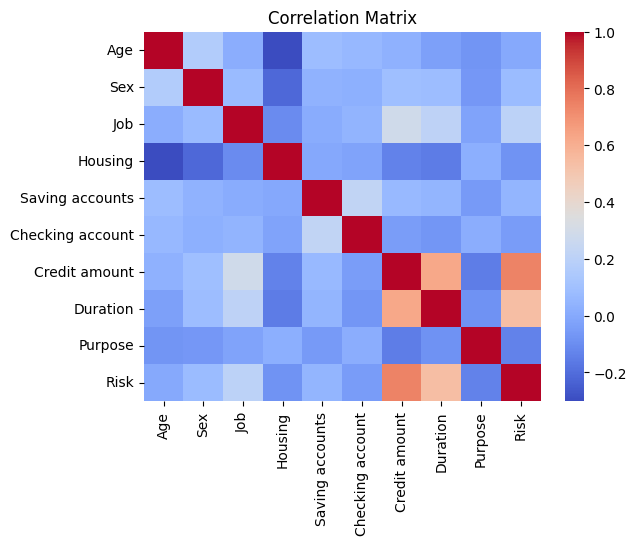

In [27]:
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## Model Saving

The trained Random Forest model is saved using pickle so that it can be reused later without retraining. This allows the model to be used in external applications like the user interface.

In [34]:
import pickle
pickle.dump(rf, open("model.pkl", "wb"))

## User Interface for Prediction

This section allows users to enter applicant details and predict credit risk using the trained model.

In [32]:
print("Enter applicant details:")

age = int(input("Age: "))

sex = input("Sex (male/female): ")
if sex == "male":
    sex = 1
else:
    sex = 0

job = int(input("Job (0 = unemployed, 1 = unskilled, 2 = skilled, 3 = highly skilled): "))

housing = input("Housing (own/rent/free): ")
if housing == "own":
    housing = 1
elif housing == "rent":
    housing = 2
else:
    housing = 0

saving = input("Saving accounts (little/moderate/rich/quite rich/unknown): ")
saving_map = {"little":0, "moderate":1, "rich":2, "quite rich":3, "unknown":4}
saving = saving_map.get(saving, 4)

checking = input("Checking account (little/moderate/rich/unknown): ")
checking_map = {"little":0, "moderate":1, "rich":2, "unknown":3}
checking = checking_map.get(checking, 3)

duration = int(input("Duration (months): "))

purpose = input("Purpose (car/furniture/radio/education/business/others): ")
purpose_map = {"car":0, "furniture":1, "radio":2, "education":3, "business":4, "others":5}
purpose = purpose_map.get(purpose, 5)

import numpy as np

input_data = np.array([[age, sex, job, housing, saving, checking, duration, purpose]])

prob = rf.predict_proba(input_data)[0][1]

print("\nPrediction Result:")

if prob < 0.3:
    print("Low Risk")
elif prob < 0.7:
    print("Medium Risk")
else:
    print("High Risk")

Enter applicant details:


Age:  24
Sex (male/female):  male
Job (0 = unemployed, 1 = unskilled, 2 = skilled, 3 = highly skilled):  1
Housing (own/rent/free):  rent
Saving accounts (little/moderate/rich/quite rich/unknown):  moderate
Checking account (little/moderate/rich/unknown):  little
Duration (months):  12
Purpose (car/furniture/radio/education/business/others):  car



Prediction Result:
High Risk


## Conclusion

This project demonstrates how machine learning can be used to assess credit risk using applicant data. Logistic Regression and Random Forest models were applied to predict whether a customer is risky or not.

After removing the "Credit amount" feature to avoid data leakage, the model performance became more realistic. The ROC-AUC scores indicate moderate performance, showing that credit risk depends on multiple factors such as age, duration, job, and account details.

A simple user interface was also developed to allow users to input applicant details and get real-time risk predictions. This makes the system more interactive and user-friendly.

Overall, this approach helps financial institutions make better and more informed loan decisions.